In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_small, ConvNeXt_Small_Weights
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seeds set!")

Seeds set!


In [3]:
TRAIN_DIR = "./train"

LABEL_MAP = {
    "bedroom": 1, "Coast": 2, "Forest": 3, "Highway": 4,
    "industrial": 5, "Insidecity": 6, "kitchen": 7, "livingroom": 8,
    "Mountain": 9, "Office": 10, "OpenCountry": 11, "store": 12,
    "Street": 13, "Suburb": 14, "TallBuilding": 15,
}
NUM_CLASSES = 15
IMG_SIZE    = 224
BATCH_SIZE  = 32
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
def load_data(data_dir):
    paths, labels = [], []
    for class_name, label in LABEL_MAP.items():
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"[WARN] Missing: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(class_dir, fname))
                labels.append(label - 1)
    return paths, labels

train_val_paths, train_val_labels = load_data(TRAIN_DIR)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.2, stratify=train_val_labels, random_state=42
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

Train: 1200 | Val: 300


In [5]:
class SceneDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds = SceneDataset(train_paths, train_labels, transform=train_transform)
val_ds   = SceneDataset(val_paths,   val_labels,   transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


print("Dataset ready!")

Dataset ready!


---

In [7]:
from torchvision.models import convnext_small, ConvNeXt_Small_Weights
set_seed(42)

LR = 1e-4

model = convnext_small(weights=ConvNeXt_Small_Weights.IMAGENET1K_V1)
model.classifier = nn.Sequential(
    nn.Flatten(start_dim=1),
    nn.LayerNorm(768),
    nn.Linear(768, NUM_CLASSES)
)

# Freeze everything first
for param in model.parameters():
    param.requires_grad = True


model = model.to(DEVICE)
print("ConvNeXt Small — unfreeze last 2 | LR=1e-4 | +hflip")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

ConvNeXt Small — unfreeze last 2 | LR=1e-4 | +hflip
Trainable params: 49,466,223


In [9]:
set_seed(42)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5,
                                                  patience=3)

best_val_acc      = 0.0
patience_counter  = 0
EARLY_STOP_PATIENCE = 7

# ← add these
train_acc_history = []
val_acc_history   = []

for epoch in range(50):
    model.train()
    train_correct, train_total = 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss    += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    train_acc    = train_correct / train_total
    val_acc      = val_correct   / val_total
    val_loss_avg = val_loss / len(val_loader)

    # ← add these
    train_acc_history.append(train_acc * 100)
    val_acc_history.append(val_acc * 100)

    scheduler.step(val_loss_avg)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Acc: {train_acc*100:.2f}% | "
          f"Val Acc: {val_acc*100:.2f}% | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "trained_cnn.pth")
        print(f"  ✓ Saved best model: {best_val_acc*100:.2f}%")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")

Epoch 01 | Train Acc: 69.00% | Val Acc: 90.00% | LR: 0.000100
  ✓ Saved best model: 90.00%
Epoch 02 | Train Acc: 96.25% | Val Acc: 92.67% | LR: 0.000100
  ✓ Saved best model: 92.67%
Epoch 03 | Train Acc: 99.17% | Val Acc: 94.00% | LR: 0.000100
  ✓ Saved best model: 94.00%
Epoch 04 | Train Acc: 99.83% | Val Acc: 93.00% | LR: 0.000100
Epoch 05 | Train Acc: 99.83% | Val Acc: 94.67% | LR: 0.000100
  ✓ Saved best model: 94.67%
Epoch 06 | Train Acc: 100.00% | Val Acc: 94.33% | LR: 0.000100
Epoch 07 | Train Acc: 100.00% | Val Acc: 94.67% | LR: 0.000100
Epoch 08 | Train Acc: 100.00% | Val Acc: 94.00% | LR: 0.000100
Epoch 09 | Train Acc: 100.00% | Val Acc: 93.00% | LR: 0.000100
Epoch 10 | Train Acc: 100.00% | Val Acc: 94.33% | LR: 0.000100
Epoch 11 | Train Acc: 100.00% | Val Acc: 93.67% | LR: 0.000050
Epoch 12 | Train Acc: 100.00% | Val Acc: 94.67% | LR: 0.000050
Early stopping at epoch 12

Best Val Accuracy: 94.67%


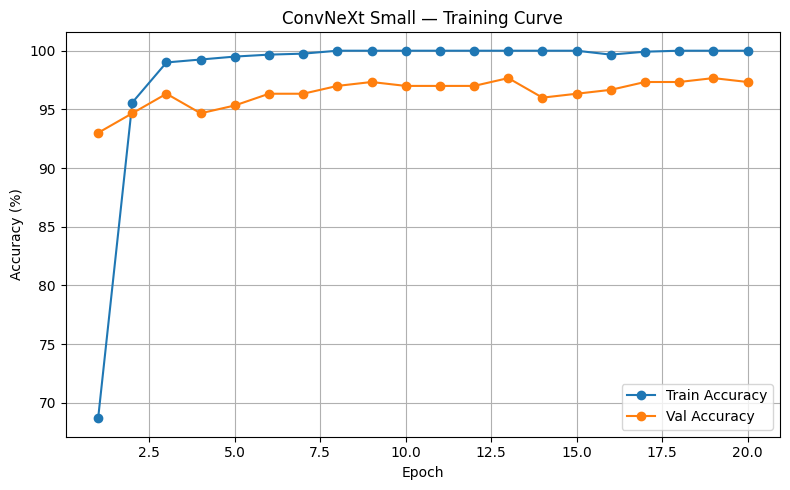

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc_history, label="Train Accuracy", marker="o")
plt.plot(epochs, val_acc_history,   label="Val Accuracy",   marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ConvNeXt Small — Training Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()

/var/tmp/ipykernel_110606/482124955.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_test.load_state_dict(torch.load("trained_cnn.pth"))


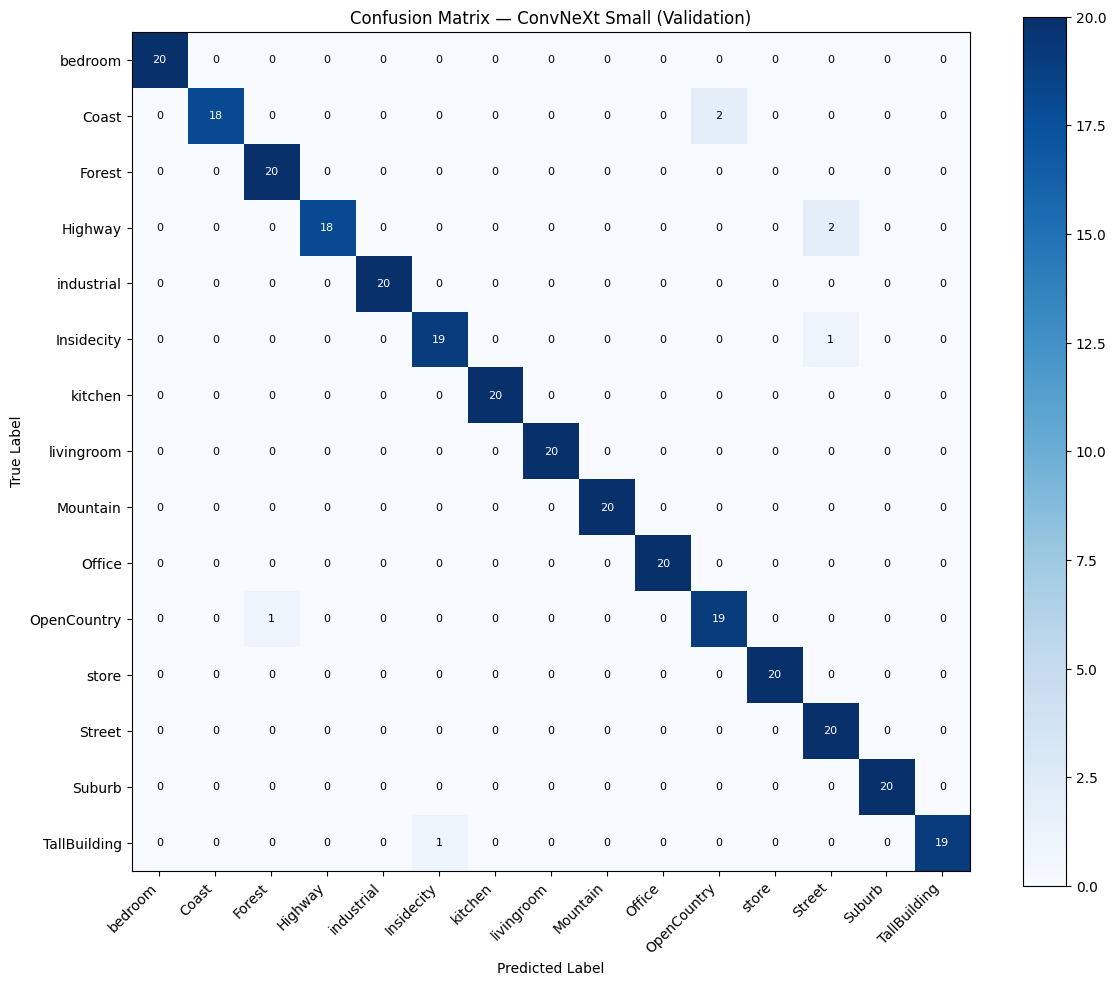

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
from torchvision.models import convnext_small

class_names = [
    "bedroom", "Coast", "Forest", "Highway", "industrial",
    "Insidecity", "kitchen", "livingroom", "Mountain", "Office",
    "OpenCountry", "store", "Street", "Suburb", "TallBuilding"
]

# Load model
model_test = convnext_small(weights=None)
model_test.classifier = nn.Sequential(
    nn.Flatten(start_dim=1),
    nn.LayerNorm(768),
    nn.Linear(768, NUM_CLASSES)
)
model_test.load_state_dict(torch.load("trained_cnn.pth"))
model_test = model_test.to(DEVICE)
model_test.eval()

# Run on validation data
val_preds, val_true = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model_test(imgs)
        preds = outputs.argmax(1)

        val_preds.extend((preds + 1).cpu().numpy())
        val_true.extend((labels + 1).cpu().numpy())

# Plot confusion matrix
cm = confusion_matrix(val_true, val_preds)

plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
plt.title("Confusion Matrix — ConvNeXt Small (Validation)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

ticks = range(len(class_names))
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=8)

plt.tight_layout()
plt.savefig("confusion_matrix_val.png", dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    val_true, val_preds,
    target_names=class_names,
    digits=4
)
print(report)

              precision    recall  f1-score   support

     bedroom     1.0000    1.0000    1.0000        20
       Coast     1.0000    0.9000    0.9474        20
      Forest     0.9524    1.0000    0.9756        20
     Highway     1.0000    0.9000    0.9474        20
  industrial     1.0000    1.0000    1.0000        20
  Insidecity     0.9500    0.9500    0.9500        20
     kitchen     1.0000    1.0000    1.0000        20
  livingroom     1.0000    1.0000    1.0000        20
    Mountain     1.0000    1.0000    1.0000        20
      Office     1.0000    1.0000    1.0000        20
 OpenCountry     0.9048    0.9500    0.9268        20
       store     1.0000    1.0000    1.0000        20
      Street     0.8696    1.0000    0.9302        20
      Suburb     1.0000    1.0000    1.0000        20
TallBuilding     1.0000    0.9500    0.9744        20

    accuracy                         0.9767       300
   macro avg     0.9784    0.9767    0.9768       300
weighted avg     0.9784   

---